# APR Pixel Reassignment

Applies **Adaptive Pixel Reassignment (APR)** to a raw BrightEyes MCS `.h5` file,
producing a new `.h5` file with the **same structure** as the input so it can be used
directly as `FILE_DATA` in `PhasorWorkflow.ipynb`.

In [1]:
from pathlib import Path
import sys

# Walk up from the current directory until the project root (containing "src") is found
ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

# Also add BrightEyes-MCS-File if it lives next to the project root
MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists() and str(MCS_FILE_SRC) not in sys.path:
    sys.path.insert(0, str(MCS_FILE_SRC))

import h5py
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import brighteyes_ism.analysis.APR_lib as apr   # shift-vector computation and reassignment
import brighteyes_ism.analysis.Graph_lib as gr  # shift-vector visualisation



## Parameters

Edit only this cell before running the notebook.

| Parameter | Description |
|---|---|
| `FILE_DATA` | Path to the raw acquisition `.h5` file |
| `FILE_OUTPUT` | Where to write the APR-reassigned `.h5` |
| `ROI` | Pixel crop `(row_start, row_end, col_start, col_end)` applied to `image[0, 0, ...]`; set to `None` to keep the full field of view |
| `REF_CHANNEL` | Index of the central detector element used as the reassignment reference (typically 12 for a 5x5 array) |
| `USF` | Up-sampling factor for sub-pixel shift estimation (higher = more accurate but slower) |
| `REASSIGN_MODE` | `'interp'` for bilinear interpolation (recommended), `'fft'` for Fourier-shift |

In [ ]:
# Path to the raw BrightEyes MCS acquisition file
FILE_DATA   = r'/home/morlando1-iit.local/manuel/18052026_flim/Convallaria.h5'

# Output file — this will be used as FILE_DATA in PhasorWorkflow.ipynb
FILE_OUTPUT = r'/home/morlando1-iit.local/manuel/18052026_flim/APR_Convallaria.h5'

# Spatial crop applied to image[0, 0, ...] as (row_start, row_end, col_start, col_end)
# Set to None to skip cropping and keep the full field of view
ROI = None #(1000, 1750, 1200, 1950)

# Index of the central detector element (reference for shift estimation)
REF_CHANNEL = 12

# Sub-pixel up-sampling factor for shift vector estimation
USF = 100

# Pixel-reassignment interpolation mode: 'interp' (bilinear) or 'fft'
REASSIGN_MODE = "interp"


FILE_DATA = '/mnt/DATA/Mixed Data/TestGiuse/Convallaria_DFD.h5'
FILE_OUTPUT = '/mnt/DATA/Mixed Data/TestGiuse/APR_Convallaria_DFD.h5'

## Step 1 — Load the raw data and estimate shift vectors

Shift vectors are computed on the **intensity image** (sum over time bins), because
the spatial offset of each detector element is time-independent.
Summing all bins maximises the SNR and makes the estimation more robust.

Cropped image shape (x, y, t_bins, channels): (512, 512, 91, 25)
Intensity image shape (x, y, channels):         (512, 512, 25)

Shift vectors (one row per channel, columns = [dy, dx]):
[[-3.13 -0.27]
 [-3.01  0.72]
 [-4.04  0.13]
 [-1.74  1.97]
 [-0.96  2.4 ]
 [-1.26 -2.14]
 [-2.18 -0.15]
 [-2.19  0.49]
 [-0.88  0.78]
 [-1.23  1.97]
 [-0.63 -0.18]
 [-0.1  -0.61]
 [ 0.    0.  ]
 [-0.7   1.18]
 [-0.13  2.76]
 [ 0.23 -0.99]
 [-0.04 -0.24]
 [ 2.65 -0.56]
 [ 3.28  1.56]
 [ 0.87  3.34]
 [ 1.65 -0.48]
 [ 1.98 -1.69]
 [ 3.26  0.4 ]
 [ 1.69  0.42]
 [ 1.11  2.94]]


/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:550: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(shift[:, 0], shift[:, 1], s=80, c=color, edgecolors='black', cmap=cmap)


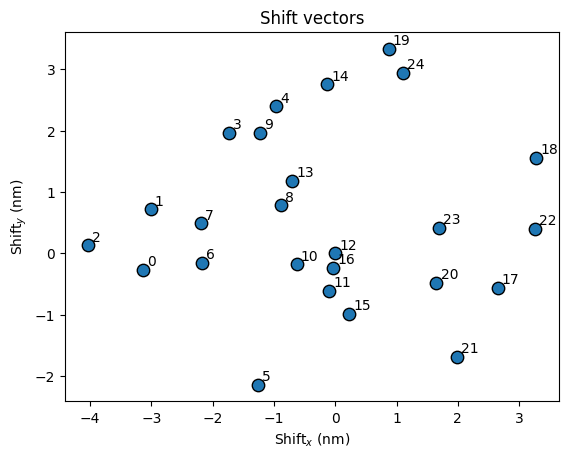

In [3]:
with h5py.File(FILE_DATA, "r") as f:
    # Raw data shape: (repetitions, z_planes, x, y, t_bins, channels)
    raw = f["data"]

    # Select the first repetition and the first z-plane -> (x, y, t_bins, channels)
    image_4D = raw[0, 0, ...]

    # Apply the spatial crop if requested
    if ROI is not None:
        r0, r1, c0, c1 = ROI
        image_4D = image_4D[r0:r1, c0:c1, ...]   # (x_crop, y_crop, t_bins, channels)

    print(f"Cropped image shape (x, y, t_bins, channels): {image_4D.shape}")

# Collapse the time axis to obtain a pure intensity image (x, y, channels).
# This is used ONLY for shift-vector estimation; the full 4-D array is kept intact.
image_intensity = np.sum(image_4D, axis=-2)
print(f"Intensity image shape (x, y, channels):         {image_intensity.shape}")

# Estimate sub-pixel shift vectors between each channel and the reference detector.
# shift_vectors: (n_channels, 2) array - one (dy, dx) pair per channel
shift_vectors, estimation_error = apr.ShiftVectors(image_intensity, usf=USF, ref=REF_CHANNEL)

print("\nShift vectors (one row per channel, columns = [dy, dx]):")
print(shift_vectors)

# Visualise the shift vectors on a grid plot
gr.PlotShiftVectors(shift_vectors)
plt.show()



## Step 2 — Apply pixel reassignment bin by bin and save the output

The reassignment is applied **separately to each time bin** so that photon
arrival-time information (needed for FLIM/phasor analysis) is fully preserved.

The output file replicates the **exact HDF5 structure** of the input
(all metadata groups and attributes included), so that `PhasorWorkflow.ipynb`
can use it as a drop-in replacement for `FILE_DATA` without any modification.

In [4]:
n_x, n_y, n_bins, n_ch = image_4D.shape

with h5py.File(FILE_DATA, "r") as f_in, h5py.File(FILE_OUTPUT, "w") as f_out:

    # Copy root-level attributes and every root object except /data.
    for attr_key, attr_val in f_in.attrs.items():
        f_out.attrs[attr_key] = attr_val

    for key in f_in.keys():
        if key == "data":
            continue
        f_in.copy(key, f_out)

    dataset_shape = (1, 1, n_x, n_y, n_bins, n_ch)
    h5_out = f_out.create_dataset(
        "data",
        shape=dataset_shape,
        dtype=np.float32,   # float32 preserves sub-pixel precision after interpolation
    )

    # Propagate dataset-level attributes from the original /data.
    for attr_key, attr_val in f_in["data"].attrs.items():
        h5_out.attrs[attr_key] = attr_val

    # Main loop: apply reassignment independently for each time bin.
    # image_4D[:, :, b, :] -> shape (x, y, channels)
    # apr.Reassignment returns the spatially-shifted (x, y, channels) array.
    for b in tqdm(range(n_bins), desc="Reassigning time bins"):
        reassigned_bin = apr.Reassignment(
            shift_vectors,
            image_4D[:, :, b, :],
            mode=REASSIGN_MODE,
        )
        # Store with rep/z wrapper axes restored.
        h5_out[0, 0, :, :, b, :] = reassigned_bin

print(f"\nAPR-reassigned file saved to:\n  {FILE_OUTPUT}")
print(f"Output dataset shape: {dataset_shape}  (rep, z, x, y, t_bins, channels)")



Reassigning time bins: 100%|██████████| 91/91 [03:57<00:00,  2.61s/it]


APR-reassigned file saved to:
  /mnt/DATA/Mixed Data/TestGiuse/APR_Coumarine_DFD.h5
Output dataset shape: (1, 1, 512, 512, 91, 25)  (rep, z, x, y, t_bins, channels)


## Step 3 — Quick sanity check

Sum over time bins and channels to produce a 2-D intensity image and compare
raw vs. reassigned side by side.

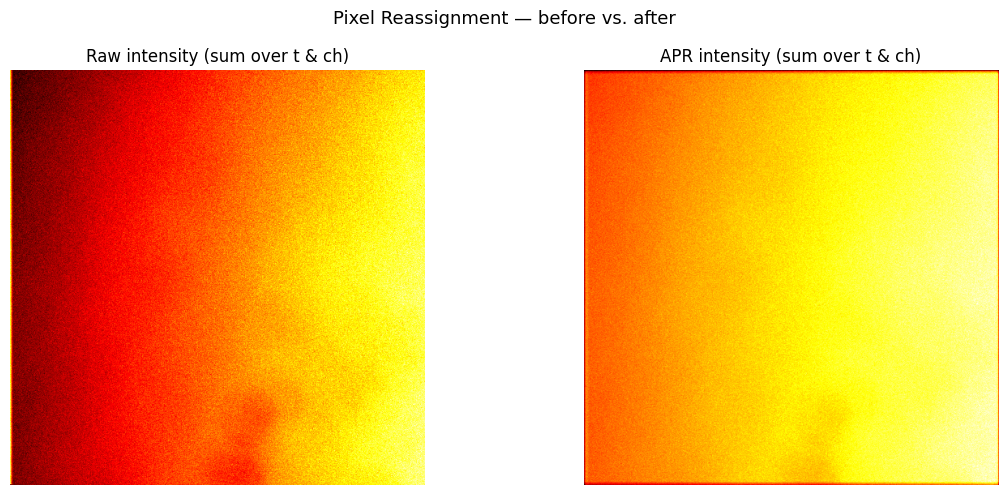

Raw image — min: 812  max: 1698
APR image — min: 260.0  max: 1698.0


In [5]:
with h5py.File(FILE_OUTPUT, "r") as f_out:
    data_apr = f_out["data"][0, 0, ...]   # (x, y, t_bins, channels)

# Collapse t_bins and channels -> 2-D intensity maps
intensity_apr = np.sum(data_apr,   axis=(-2, -1))
intensity_raw = np.sum(image_4D,   axis=(-2, -1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(intensity_raw, cmap="hot", origin="lower")
axes[0].set_title("Raw intensity (sum over t & ch)")
axes[0].axis("off")

axes[1].imshow(intensity_apr, cmap="hot", origin="lower")
axes[1].set_title("APR intensity (sum over t & ch)")
axes[1].axis("off")

fig.suptitle("Pixel Reassignment — before vs. after", fontsize=13)
fig.tight_layout()
plt.show()

print(f"Raw image — min: {intensity_raw.min():.0f}  max: {intensity_raw.max():.0f}")
print(f"APR image — min: {intensity_apr.min():.1f}  max: {intensity_apr.max():.1f}")




## Next step

Open `PhasorWorkflow.ipynb` and set:

```python
FILE_DATA = r"<same path as FILE_OUTPUT above>"
```

All other parameters remain unchanged. The calibration and phasor analysis
will now operate on the spatially-reassigned data.